# Lecture 8 — From Sensor Data to a Dataset

**01211271 Industrial AI and IoT** · Electromechanical Manufacturing Engineering

---

In the first half of this course you built an IoT pipeline: a sensor, an ESP32 running
MicroPython, and a path to NETPIE. Every decision in that pipeline was made by a
threshold you chose by hand.

This week we start replacing those thresholds with something learned. Before any
learning can happen, though, a stream of accelerometer samples has to become a
**table** — rows and columns that a machine-learning algorithm will accept. Getting
that table right is most of the work, and getting it wrong is the most common way an
industrial ML project fails while appearing to succeed.

## Learning objectives

By the end of this notebook you should be able to:

1. Choose a sampling rate from the physics of the fault you are trying to detect.
2. Cut a continuous signal into windows and explain what the window length buys and costs.
3. Compute seven time-domain and five frequency-domain features, and say what each one measures.
4. Assemble a labelled learning table with one row per window.
5. Split that table so the reported accuracy is honest — and demonstrate the inflation you get when you do not.
6. Decide when feature scaling matters and when it is a ritual.

## Prerequisites

Nyquist sampling and anti-alias filtering (Week 3), the FFT (Week 4), ESP32
timing and the MicroPython file system (Weeks 5–6), and basic NumPy.

## The running example

A small motor-driven rotor rig. A three-phase induction motor turns a rotor disc
carried on two rolling-element bearings; a MEMS accelerometer is bolted radially to
the drive-end bearing housing and sampled at 2000 Hz.

We will work with three machine states:

| state | mechanism | what you expect to see |
|---|---|---|
| `normal` | residual unbalance only | modest 1× shaft-rate component |
| `imbalance` | trial mass added to the disc | large 1× component |
| `bearing` | outer-race spall | periodic impulses that ring the housing |

For an outer-race defect with $n = 9$ balls, ball-to-pitch diameter ratio $d/D = 0.2$
and contact angle $\phi = 0$:

$$\text{BPFO} = \frac{n}{2}\left(1 - \frac{d}{D}\cos\phi\right) f_r
= 4.5 \times 0.8 \times f_r = 3.6\, f_r$$

so at a nominal 30 Hz shaft rate (1800 rpm) the impulses arrive at **108 Hz**.

___
### Aside 

#### Outer Race Spall

An **outer race spall** is a flaking or chipping defect on the stationary outer ring track of a rolling element bearing, caused by metal fatigue under repeated cyclic contact stress. [Reliability Solutions](https://reliabilitysolutions.net/resources/blog/bearing-spalling-how-it-starts-how-it-spreads-and-the-warning-signs-your-team-can-catch-early/), [duhui-bearing.com](https://duhui-bearing.com/ball-bearings-inner-vs-outer-races-difference/)

#### What is a Spall?

* Definition: A jagged, irregular crater where microscopic pieces of metal have flaked off the raceway surface.
* Cause: Subsurface or surface fatigue, heavy loads, poor lubrication, or contamination.
* Mechanism: Every time a rolling element (ball or roller) strikes the damaged cavity, it creates a distinct mechanical impact. [sciencedirect.com](https://www.sciencedirect.com/science/article/abs/pii/S0022460X26002051), [tribonet.org](https://www.tribonet.org/wiki/spalling-damage/), [etasr.com](https://www.etasr.com/index.php/ETASR/article/download/14210/5935), [reliability solutions](https://reliabilitysolutions.net/resources/blog/bearing-spalling-how-it-starts-how-it-spreads-and-the-warning-signs-your-team-can-catch-early/)

#### Characteristics of an Outer Race Spall

* Stationary Defect: Unlike inner race spalls (which rotate with the shaft), an outer race spall stays fixed in one position within the housing. [duhui-bearing.com](https://duhui-bearing.com/ball-bearings-inner-vs-outer-races-difference/), [reliability solutions](https://reliabilitysolutions.net/resources/blog/bearing-spalling-how-it-starts-how-it-spreads-and-the-warning-signs-your-team-can-catch-early/)
* Load Zone: If the spall is located inside the bearing's primary load zone, every rolling element passing through hits the edge of the crater, generating a constant and predictable frequency known as BPFO (Ball Pass Frequency Outer Race). [reliability solutions](https://reliabilitysolutions.net/resources/blog/bearing-spalling-how-it-starts-how-it-spreads-and-the-warning-signs-your-team-can-catch-early/)
* Double-Impulse Response: Vibration signals typically show a characteristic double-impulse pattern—one when the rolling element enters the spall and another when it exits. [PHM Society](https://papers.phmsociety.org/index.php/phme/article/download/1618/581), [jvs.sjtu.edu.cn](https://jvs.sjtu.edu.cn/EN/Y2017/V36/I4/1)


BPFO stands for Ball Pass Frequency, Outer Race, which is a characteristic vibration frequency used in motor condition monitoring to detect defects on a bearing's stationary outer raceway.

#### How BPFO Works

* Definition: It is the exact rate at which rolling elements (balls or rollers) strike a specific flaw, crack, or pit on the stationary outer ring of a [rolling-element bearing](https://vibromera.eu/glossary/bpfo/)

* Calculation: BPFO is a non-integer multiple of the motor's shaft rotational speed, determined entirely by the internal geometry of the bearing (number of balls, ball diameter, pitch diameter, and contact angle). [IoT Bearings](https://iotbearings.com/bearing-defect-frequencies-bpfo-bpfi-bsf-ftf-explained/), [Harmony AI](https://www.tryharmony.ai/bearing-defect-frequencies)

* Typical Range: For standard motor bearings, BPFO typically appears at about 3 to 5 times the running speed of the shaft. [Vibromera EU 1](https://vibromera.eu/glossary/bearing-fault-frequencies/), [Vibromera EU 2](https://vibromera.eu/glossary/bpfo/)

#### Why BPFO is Important

* Early Fault Detection: When a bearing starts to degrade, an impact spike shows up in vibration analysis at the BPFO frequency and its harmonics. [IFactory AI](https://ifactoryapp.com/blog/bearing-failure-analysis-vibration), [IoT Bearings](https://iotbearings.com/bearing-defect-frequencies-bpfo-bpfi-bsf-ftf-explained/)

* Predictive Maintenance: Monitoring BPFO allows engineers to identify outer-race damage months before the motor becomes loud, overheats, or experiences catastrophic failure. [YouTube : Yuelfi Engineering](https://www.youtube.com/watch?v=dHZ71Q0C-kY), [Vibromera.eu](https://vibromera.eu/glossary/bpfo/), [Harmony AI](https://www.tryharmony.ai/bearing-defect-frequencies)
___

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn

print("python     ", sys.version.split()[0])
for m in (np, pd, matplotlib, sklearn):
    print(f"{m.__name__:<11}", m.__version__)

plt.rcParams.update({"figure.figsize": (10.5, 3.6), "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.35,
                     "axes.spines.top": False, "axes.spines.right": False})
CCOL = {"normal": "#2a78d6", "imbalance": "#eb6834", "bearing": "#4a3aa7"}

python      3.11.15
numpy       2.4.4
pandas      3.0.2
matplotlib  3.10.9
sklearn     1.8.0


## The data

We have no rotor rig in this room, so we synthesise one. The generator below is not
`make_classification` — every term in it corresponds to something mechanical, and the
fault signatures are placed where the physics puts them.

Read it carefully. The part that matters most for this week is `_run_params`: each
**acquisition run** gets its own shaft speed, sensor gain, noise floor, DC bias and
frame resonance. That is what a real workshop looks like — you never record the same
machine twice under identical conditions — and it is the reason §5 of this notebook
exists.

In [2]:
"""
Week 8 — From Sensor Data to a Dataset
01211271 Industrial AI and IoT

Synthetic but physics-motivated vibration data for a small motor-driven rotor rig.

Rig model
---------
A 3-phase induction motor drives a rotor disc supported by two rolling-element
bearings.  A MEMS accelerometer is mounted radially on the drive-end bearing
housing and sampled at fs = 2000 Hz.

Three machine states are simulated:

  normal    : residual unbalance only -> modest 1x shaft-rate component
  imbalance : added trial mass on the disc -> large 1x component
  bearing   : outer-race spall -> periodic impulses at BPFO that ring the
              bearing housing resonance

Outer-race defect frequency, for a bearing with n = 9 balls, ball/pitch
diameter ratio d/D = 0.2 and contact angle 0:

    BPFO = (n/2) * (1 - (d/D) cos(phi)) * f_r = 4.5 * 0.8 * f_r = 3.6 * f_r

so at a nominal 30 Hz shaft rate (1800 rpm) the impulses arrive at 108 Hz.

Every run carries its own nuisance variation -- shaft speed, sensor gain,
broadband noise floor, DC bias and a structural tone.  This is what makes a
random train/test split across overlapping windows dishonest: the model can
memorise the run, not the fault.
"""

import numpy as np

# ----------------------------------------------------------------- constants
FS = 2000.0                 # sampling rate, Hz
RUN_SECONDS = 4.0           # length of one acquisition run
RUNS_PER_CLASS = 16
CLASSES = ("normal", "imbalance", "bearing")

WIN = 256                   # default window length, samples (128 ms)
HOP = 128                   # 50 % overlap

F_RESONANCE = 600.0         # bearing housing resonance, Hz
TAU_RING = 0.0012           # impulse ring-down time constant, s
BPFO_RATIO = 3.6            # outer-race defect order

# Fixed analysis bands, Hz.  Shaft speed wanders over 28-32 Hz, so the bands
# are wide enough to hold the order they are named for without a tachometer.
BANDS = {
    "e_1x":   (20.0, 42.0),     # shaft rate
    "e_2x":   (48.0, 78.0),     # twice shaft rate
    "e_bpfo": (90.0, 132.0),    # outer-race defect order
    "e_hi":   (400.0, 900.0),   # housing resonance region
}

FEATURE_NAMES = [
    "mean", "rms", "std", "ptp", "crest", "kurt", "zcr",
    "dom_freq", "e_1x", "e_2x", "e_bpfo", "e_hi",
]


# ------------------------------------------------------------ signal synthesis
def _run_params(rng, state):
    """Nuisance parameters that vary from one acquisition run to the next."""
    return dict(
        f_r=rng.uniform(28.0, 32.0),          # shaft rate, Hz
        gain=rng.uniform(0.85, 1.25),         # sensor / mounting gain
        noise=rng.uniform(0.04, 0.20),        # broadband floor, g rms
        bias=rng.uniform(-0.06, 0.06),        # accelerometer DC offset, g
        f_struct=rng.uniform(150.0, 700.0),   # frame resonance -- a confounder
        a_struct=rng.uniform(0.03, 0.15),
        a_1x=(rng.uniform(0.20, 0.38) if state != "imbalance"
              else rng.uniform(0.58, 1.10)),
        a_imp=(rng.uniform(0.45, 1.40) if state == "bearing" else 0.0),
    )


def make_run(rng, state, seconds=RUN_SECONDS, fs=FS):
    """Synthesise one acquisition run.  Returns (signal, params)."""
    p = _run_params(rng, state)
    n = int(seconds * fs)
    t = np.arange(n) / fs

    ph = rng.uniform(0, 2 * np.pi, 4)
    x = (p["a_1x"] * np.sin(2 * np.pi * p["f_r"] * t + ph[0])
         + 0.32 * p["a_1x"] * np.sin(2 * np.pi * 2 * p["f_r"] * t + ph[1])
         + 0.12 * p["a_1x"] * np.sin(2 * np.pi * 3 * p["f_r"] * t + ph[2])
         + p["a_struct"] * np.sin(2 * np.pi * p["f_struct"] * t + ph[3]))

    if p["a_imp"] > 0:
        f_bpfo = BPFO_RATIO * p["f_r"]
        period = fs / f_bpfo
        k = 0
        while True:
            # 1 % random slip, as real rolling elements do
            idx = int(k * period * (1.0 + rng.normal(0, 0.01)))
            if idx >= n:
                break
            tail = np.arange(n - idx) / fs
            ring = (p["a_imp"] * rng.uniform(0.75, 1.25)
                    * np.exp(-tail / TAU_RING)
                    * np.sin(2 * np.pi * F_RESONANCE * tail))
            x[idx:] += ring
            k += 1

    x = p["gain"] * (x + rng.normal(0, p["noise"], n)) + p["bias"]
    return x.astype(np.float64), p


def make_dataset(seed=7, runs_per_class=RUNS_PER_CLASS):
    """All runs.  Returns list of dicts with signal, label and run id."""
    rng = np.random.default_rng(seed)
    runs, rid = [], 0
    for state in CLASSES:
        for _ in range(runs_per_class):
            x, p = make_run(rng, state)
            runs.append({"x": x, "label": state, "run": rid, "params": p})
            rid += 1
    return runs


# ------------------------------------------------------------------- features
def frame(x, win=WIN, hop=HOP):
    """Slice a 1-D signal into overlapping windows -> (n_windows, win)."""
    n = 1 + (len(x) - win) // hop
    idx = np.arange(win)[None, :] + hop * np.arange(n)[:, None]
    return x[idx]


def time_features(w):
    """Seven time-domain features for each row of w."""
    mean = w.mean(axis=1)
    ac = w - mean[:, None]                      # remove DC before anything else
    rms = np.sqrt((ac ** 2).mean(axis=1))
    std = ac.std(axis=1)
    ptp = np.ptp(w, axis=1)
    peak = np.abs(ac).max(axis=1)
    crest = peak / np.maximum(rms, 1e-12)
    m4 = (ac ** 4).mean(axis=1)
    kurt = m4 / np.maximum(rms, 1e-12) ** 4     # non-excess kurtosis; 3.0 = Gaussian
    zc = np.diff(np.signbit(ac).astype(np.int8), axis=1)
    zcr = np.abs(zc).sum(axis=1) / (w.shape[1] - 1)
    return np.column_stack([mean, rms, std, ptp, crest, kurt, zcr])


def freq_features(w, fs=FS, normalise=True):
    """Dominant frequency plus four band energies.

    normalise=True gives each band as a fraction of the window's total power,
    which makes the feature independent of sensor gain.  normalise=False gives
    the absolute band power, whose units and magnitude differ wildly from the
    time-domain features -- useful for showing when feature scaling matters.
    """
    n = w.shape[1]
    win = np.hanning(n)
    ac = w - w.mean(axis=1, keepdims=True)
    spec = np.abs(np.fft.rfft(ac * win, axis=1)) ** 2
    f = np.fft.rfftfreq(n, 1.0 / fs)
    spec[:, 0] = 0.0                            # DC carries no information here
    total = np.maximum(spec.sum(axis=1), 1e-20)

    dom = f[spec.argmax(axis=1)]
    cols = [dom]
    for lo, hi in BANDS.values():
        m = (f >= lo) & (f < hi)
        band = spec[:, m].sum(axis=1)
        cols.append(band / total if normalise else band)
    return np.column_stack(cols)


def features_of(w, fs=FS, normalise=True):
    """Full 12-feature vector for each row of w."""
    return np.column_stack([time_features(w), freq_features(w, fs, normalise)])


def build_table(runs, win=WIN, hop=HOP, fs=FS, normalise=True):
    """Turn the raw runs into the (X, y, groups) learning problem."""
    X, y, g = [], [], []
    for r in runs:
        w = frame(r["x"], win, hop)
        X.append(features_of(w, fs, normalise))
        y += [r["label"]] * w.shape[0]
        g += [r["run"]] * w.shape[0]
    return np.vstack(X), np.array(y), np.array(g)


def raw_table(runs, win=WIN, hop=HOP):
    """The naive alternative: the raw samples of each window as the features."""
    X, y, g = [], [], []
    for r in runs:
        w = frame(r["x"], win, hop)
        X.append(w)
        y += [r["label"]] * w.shape[0]
        g += [r["run"]] * w.shape[0]
    return np.vstack(X), np.array(y), np.array(g)

48 runs, 16 per class, 8000 samples each


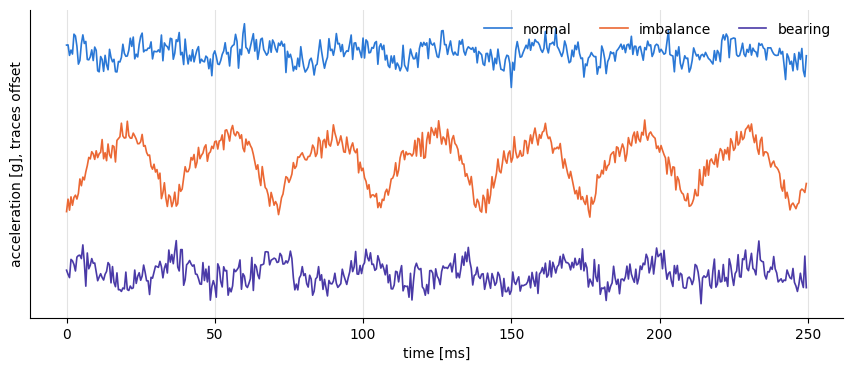

In [3]:
runs = make_dataset(seed=7)
print(f"{len(runs)} runs, {RUNS_PER_CLASS} per class, "
      f"{int(RUN_SECONDS * FS)} samples each")

fig, ax = plt.subplots(figsize=(10.5, 4.0))
i0, i1 = int(1.0 * FS), int(1.25 * FS)
for k, c in enumerate(CLASSES):
    r = next(r for r in runs if r["label"] == c)
    ax.plot((np.arange(i0, i1) / FS - 1.0) * 1000, r["x"][i0:i1] - 3.4 * k,
            color=CCOL[c], lw=1.2, label=c)
ax.set_xlabel("time [ms]")
ax.set_ylabel("acceleration [g], traces offset")
ax.set_yticks([])
ax.legend(loc="upper right", ncol=3, frameon=False)
plt.show()

## 1. Sampling rate and windowing

### 1.1 Choose $f_s$ from the fault, not from the shaft

A beginner's instinct is to sample "a bit faster than the shaft speed" — 30 Hz shaft,
so maybe 200 Hz. That is enough to see imbalance and completely blind to the bearing,
because the bearing fault announces itself through a **600 Hz housing resonance**.

Anything above $f_s/2$ does not disappear. It folds back and appears at a frequency
that is not in the machine. Below, a 600 Hz ring sampled at 800 Hz lands exactly on a
200 Hz wave.

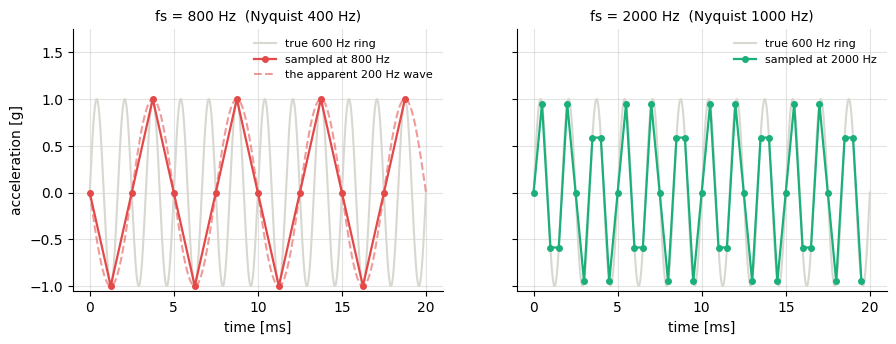

aliased frequency = 200 Hz


In [4]:
t = np.linspace(0, 0.02, 4000)
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.4), sharey=True)
for a, fs_s, col, ttl in ((ax[0], 800.0, "#e34948", "fs = 800 Hz  (Nyquist 400 Hz)"),
                          (ax[1], 2000.0, "#1baf7a", "fs = 2000 Hz  (Nyquist 1000 Hz)")):
    ts = np.arange(0, 0.02, 1 / fs_s)
    a.plot(t * 1000, np.sin(2 * np.pi * 600 * t), color="#d8d7d0", lw=1.5,
           label="true 600 Hz ring")
    a.plot(ts * 1000, np.sin(2 * np.pi * 600 * ts), "-o", color=col, ms=4, lw=1.6,
           label=f"sampled at {fs_s:.0f} Hz")
    a.set_title(ttl, fontsize=10)
    a.set_xlabel("time [ms]")
ax[0].plot(t * 1000, -np.sin(2 * np.pi * 200 * t), "--", color="#e34948", alpha=0.55,
           label="the apparent 200 Hz wave")
ax[0].set_ylabel("acceleration [g]")
ax[0].set_ylim(-1.05, 1.75)
for a in ax:
    a.legend(loc="upper right", fontsize=8, frameon=False, ncol=1)
plt.show()

print("aliased frequency =", abs(600 - 800), "Hz")

The rule for this course: **pick $f_s$ from the highest frequency that carries fault
information, then put a real anti-alias filter in front of the ADC.** Here the housing
resonance is at 600 Hz, so $f_s = 2000$ Hz gives comfortable headroom.

### 1.2 Cut the stream into windows

A classifier needs a fixed-length input. A 4-second run is 8000 samples; we slide a
window of $N$ samples across it with a hop of $N/2$ (50 % overlap) and compute one
feature vector per window.

In [5]:
w = frame(runs[0]["x"], WIN, HOP)
print(f"window  N = {WIN} samples = {1000*WIN/FS:.0f} ms")
print(f"hop     H = {HOP} samples = {1000*HOP/FS:.0f} ms  (50 % overlap)")
print(f"one 4 s run -> {w.shape[0]} windows of {w.shape[1]} samples")
print(f"frequency resolution df = fs/N = {FS/WIN:.2f} Hz")

window  N = 256 samples = 128 ms
hop     H = 128 samples = 64 ms  (50 % overlap)
one 4 s run -> 61 windows of 256 samples
frequency resolution df = fs/N = 7.81 Hz


Two consequences to keep in mind — we will come back to both:

* **Resolution.** The FFT of an $N$-sample window has bins spaced $f_s/N$ apart. At
  $N = 256$ that is 7.81 Hz, so the 1× line at 30 Hz and the 2× line at 60 Hz are four
  bins apart: resolvable. At $N = 64$ the spacing is 31.25 Hz and they collapse into
  neighbouring bins.
* **Overlap.** Window $k$ and window $k+1$ share half their samples. Their feature
  vectors are therefore *not* independent observations. Remember this.

## 2. Time-domain features

Seven numbers, each answering a different question about the window.

| feature | formula | what it measures |
|---|---|---|
| `mean` | $\bar{x}$ | sensor DC bias — not machine information |
| `rms` | $\sqrt{\overline{(x-\bar{x})^2}}$ | overall vibration energy — "how much" |
| `std` | same as RMS after DC removal | dispersion |
| `ptp` | $\max x - \min x$ | full excursion, outlier-sensitive |
| `crest` | $\text{peak}/\text{RMS}$ | how spiky — "what shape" |
| `kurt` | $\overline{(x-\bar{x})^4}/\text{RMS}^4$ | tail weight; 3.0 for Gaussian noise |
| `zcr` | sign changes per sample | rough proxy for dominant frequency |

Two habits worth forming now:

1. **Remove the DC component before computing anything else.** An accelerometer's bias
   varies with temperature and mounting; leave it in and `zcr` becomes meaningless and
   `crest` becomes a measure of your bias, not your machine.
2. **RMS alone cannot diagnose.** It tells you the machine is vibrating more, not why.
   A loaded machine and a faulty machine both raise RMS.

In [6]:
tf = pd.DataFrame(time_features(w),
                  columns=["mean", "rms", "std", "ptp", "crest", "kurt", "zcr"])
tf.insert(0, "window", np.arange(len(tf)))
print("first five windows of run 0 (a 'normal' run):")
tf.head().round(3)

first five windows of run 0 (a 'normal' run):


,window,mean,rms,std,ptp,crest,kurt,zcr
0,0,-0.057,0.268,0.268,1.531,2.997,2.858,0.329
1,1,-0.041,0.268,0.268,1.330,2.513,2.674,0.298
2,2,-0.050,0.282,0.282,1.386,2.499,2.544,0.290
3,3,-0.059,0.297,0.297,1.443,2.437,2.597,0.318
4,4,-0.035,0.305,0.305,1.464,2.451,2.411,0.286


In [7]:
rows = []
for c in CLASSES:
    acc = [time_features(frame(r["x"], WIN, HOP))
           for r in runs if r["label"] == c]
    rows.append(np.vstack(acc).mean(axis=0))
summary = pd.DataFrame(rows, index=list(CLASSES),
                       columns=["mean", "rms", "std", "ptp", "crest", "kurt", "zcr"])
summary.round(3)

,mean,rms,std,ptp,crest,kurt,zcr
normal,-0.001,0.277,0.277,1.318,2.537,2.374,0.203
imbalance,0.015,0.658,0.658,2.596,2.139,1.948,0.087
bearing,0.013,0.323,0.323,1.860,3.294,3.173,0.269


Read that table before moving on.

* `rms` separates **imbalance** cleanly — the added mass simply moves more metal.
  It does almost nothing for the bearing fault: an early spall is a small amount of
  energy delivered very sharply.
* `crest` and `kurt` do the opposite. They ignore how much and ask how spiky, and
  both jump for the bearing fault.

This is the whole argument for feature engineering in one table. RMS answers
*how much*; crest factor and kurtosis answer *what shape*. A diagnosis needs both.

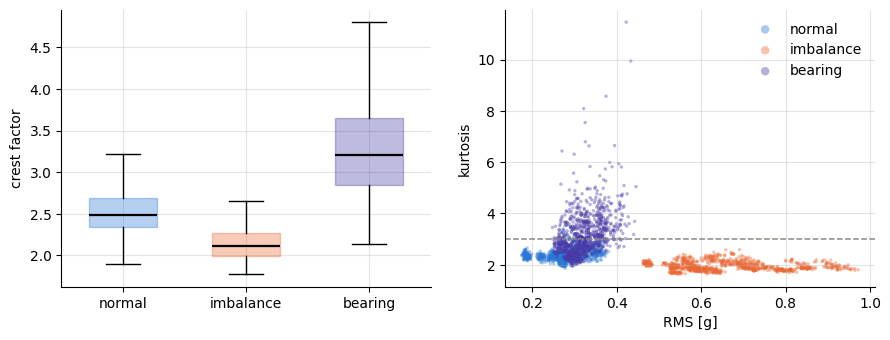

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
X_all, y_all, g_all = build_table(runs)
ci = {k: FEATURE_NAMES.index(k) for k in ("rms", "crest", "kurt")}

bp = ax[0].boxplot([X_all[y_all == c, ci["crest"]] for c in CLASSES],
                   patch_artist=True, widths=0.55, showfliers=False,
                   medianprops=dict(color="black", lw=1.6))
for patch, c in zip(bp["boxes"], CLASSES):
    patch.set_facecolor(CCOL[c]); patch.set_alpha(0.35); patch.set_edgecolor(CCOL[c])
ax[0].set_xticks([1, 2, 3]); ax[0].set_xticklabels(CLASSES)
ax[0].set_ylabel("crest factor")

for c in CLASSES:
    m = y_all == c
    ax[1].scatter(X_all[m, ci["rms"]], X_all[m, ci["kurt"]], s=6, alpha=0.4,
                  color=CCOL[c], label=c, edgecolors="none")
ax[1].axhline(3.0, color="#898781", ls="--", lw=1.1)
ax[1].set_xlabel("RMS [g]"); ax[1].set_ylabel("kurtosis")
ax[1].legend(markerscale=2.5, frameon=False)
plt.show()

## 3. Frequency-domain features

The time-domain features throw away all phase and frequency structure. For rotating
machinery that structure *is* the diagnosis, so we add five more features computed
from the FFT of each window:

* `dom_freq` — the frequency of the largest bin.
* four **band energies**, each the fraction of the window's total power falling inside
  a fixed frequency band.

Two design decisions are worth arguing about:

**Why fixed bands in Hz rather than shaft orders?** Order tracking (bands at exactly
1×, 2×, 3.6× of the measured shaft speed) is sharper, but it needs a tachometer. Our
rig has none, and the shaft wanders between 28 and 32 Hz, so we use bands wide enough
to contain the order they are named for.

**Why a fraction of total power rather than absolute power?** Because the fraction is
independent of sensor gain and mounting. A loose accelerometer halves every absolute
number; it barely touches the ratios. We will see the second benefit in §7.

e_1x       20.0 –   42.0 Hz
e_2x       48.0 –   78.0 Hz
e_bpfo     90.0 –  132.0 Hz
e_hi      400.0 –  900.0 Hz


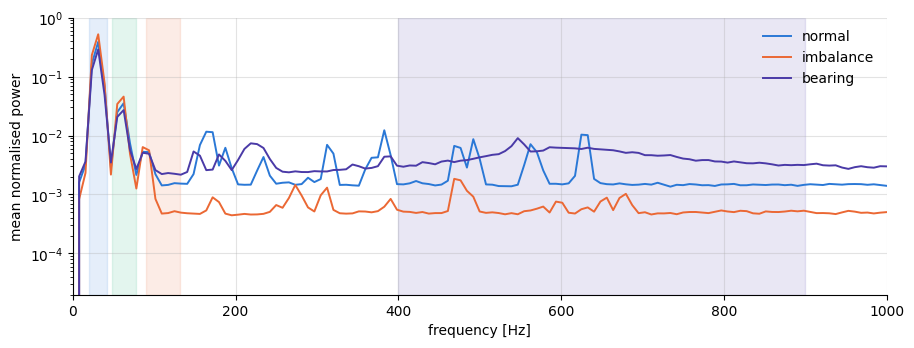

In [9]:
for name, (lo, hi) in BANDS.items():
    print(f"{name:<8} {lo:6.1f} – {hi:6.1f} Hz")

f = np.fft.rfftfreq(WIN, 1 / FS)
fig, ax = plt.subplots(figsize=(10.5, 3.6))
for c in CLASSES:
    acc = []
    for r in [r for r in runs if r["label"] == c]:
        ww = frame(r["x"], WIN, HOP)
        sp = np.abs(np.fft.rfft((ww - ww.mean(1, keepdims=True))
                                * np.hanning(WIN), axis=1)) ** 2
        sp[:, 0] = 0.0
        acc.append((sp / sp.sum(1, keepdims=True)).mean(0))
    ax.semilogy(f, np.mean(acc, 0), color=CCOL[c], lw=1.4, label=c)
for (name, (lo, hi)), col in zip(BANDS.items(),
                                 ["#2a78d6", "#1baf7a", "#eb6834", "#4a3aa7"]):
    ax.axvspan(lo, hi, color=col, alpha=0.12)
ax.set_xlim(0, 1000); ax.set_ylim(2e-5, 1)
ax.set_xlabel("frequency [Hz]"); ax.set_ylabel("mean normalised power")
ax.legend(frameon=False)
plt.show()

In [10]:
bands = pd.DataFrame(
    [[X_all[y_all == c, FEATURE_NAMES.index(n)].mean() for n in BANDS]
     for c in CLASSES], index=list(CLASSES), columns=list(BANDS))
bands.round(3)

,e_1x,e_2x,e_bpfo,e_hi
normal,0.619,0.068,0.012,0.146
imbalance,0.828,0.085,0.008,0.038
bearing,0.465,0.053,0.014,0.289


Now look at `e_bpfo`. We built that band specifically to catch the outer-race defect
frequency, and it is **worthless** — 0.012 for a healthy machine against 0.014 for a
damaged one.

That is not a bug in the code; it is mechanics. A spall delivers a short impulse, and
an impulse excites whatever is nearby that likes to ring — the bearing housing at
600 Hz. The energy ends up in the resonance, not at the 108 Hz repetition rate. The
band that actually separates the bearing fault is `e_hi` (0.146 → 0.289).

Two lessons:

1. **A feature you designed on a whiteboard is a hypothesis, not a fact.** Check it
   against data. In Week 9 we will let feature-importance measures make this
   judgement for us instead of doing it by eye.
2. The technique for recovering the 108 Hz periodicity *is* standard — it is called
   **envelope analysis**, and it demodulates the resonance before taking the FFT. It
   is outside our scope, but it is the right next thing to read if machine diagnostics
   interests you.

## 4. The learning table

Twelve features per window, one row per window, plus two bookkeeping columns:
the **label** (what we want to predict) and the **run id** (which acquisition the row
came from). That run id looks like clutter. It is the most important column in the
table, and §5 explains why.

In [11]:
X, y, groups = build_table(runs)
df = pd.DataFrame(X, columns=FEATURE_NAMES)
df["label"] = y
df["run"] = groups
print("learning table:", df.shape)
print(df["label"].value_counts().to_string())
df.head(4).round(3)

learning table: (2928, 14)
label
normal       976
imbalance    976
bearing      976


,mean,rms,std,ptp,crest,kurt,zcr,dom_freq,e_1x,e_2x,e_bpfo,e_hi,label,run
0,-0.057,0.268,0.268,1.531,2.997,2.858,0.329,31.25,0.382,0.032,0.016,0.252,normal,0
1,-0.041,0.268,0.268,1.330,2.513,2.674,0.298,31.25,0.377,0.048,0.013,0.230,normal,0
2,-0.050,0.282,0.282,1.386,2.499,2.544,0.290,31.25,0.322,0.075,0.013,0.194,normal,0
3,-0.059,0.297,0.297,1.443,2.437,2.597,0.318,31.25,0.418,0.081,0.008,0.178,normal,0


## 5. Splitting the data — the trap

Here is the code almost everyone writes first:

```python
# WRONG for this dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
```

`train_test_split` shuffles rows and deals them into two piles. That is correct when
rows are independent observations. Ours are not, for two separate reasons:

1. **Overlap.** Window $k$ and window $k+1$ share half their samples. Put one in train
   and the other in test and the model has already seen most of the "unseen" data.
2. **Run identity.** Every run has its own shaft speed, gain, noise floor and frame
   resonance. A model can learn *"this is run 23"* and read the label off that,
   because all of run 23's rows carry the same label.

The fix is to split by **group**, keeping every window of a run on the same side.
`GroupShuffleSplit` does exactly that.

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit

def tree():
    return DecisionTreeClassifier(max_depth=6, random_state=0)

def random_split_score(A, B, seeds=8):
    out = []
    for s in range(seeds):
        Atr, Ate, Btr, Bte = train_test_split(A, B, test_size=0.3,
                                              random_state=s, stratify=B)
        out.append(tree().fit(Atr, Btr).score(Ate, Bte))
    return float(np.mean(out))

def grouped_split_score(A, B, G, seeds=8):
    out = []
    for s in range(seeds):
        tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.3,
                                        random_state=s).split(A, B, G))
        out.append(tree().fit(A[tr], B[tr]).score(A[te], B[te]))
    return float(np.mean(out))

Xraw, yraw, graw = raw_table(runs)     # the 256 raw samples as 'features'

res = pd.DataFrame(
    {"random split": [random_split_score(Xraw, yraw), random_split_score(X, y)],
     "split by run": [grouped_split_score(Xraw, yraw, graw),
                      grouped_split_score(X, y, groups)]},
    index=["256 raw samples", "12 features"])
res["inflation"] = res["random split"] - res["split by run"]
res.round(3)

,random split,split by run,inflation
256 raw samples,0.616,0.537,0.079
12 features,0.933,0.810,0.123


Read the two columns as two different questions.

*Random split* answers: **"given more windows from machines I have already recorded,
can I classify them?"** — 0.933. Almost nobody wants the answer to that question.

*Split by run* answers: **"given a machine I have never recorded, can I classify it?"**
— 0.810. That is the number you would have to defend to a maintenance engineer, and
it is 0.123 lower.

Notice also the left column of the table: on 256 raw samples the honest accuracy is
0.537, barely above the 0.333 you would get by guessing. Twelve well-chosen features
buy **+0.273**. The raw window is nearly useless because its samples arrive at a
random phase — sample 40 of a window means nothing on its own.

> **The rule.** If rows share a source — the same run, the same machine, the same
> shift, the same patient — split on that source. Reporting a random-split number on
> grouped data is the single most common way industrial ML projects claim a success
> that does not survive deployment.

## 6. How long should the window be?

Longer windows give finer frequency resolution and average away more noise, so
accuracy rises. They also cost proportionally more latency and more RAM on the ESP32 —
and the window length is a hard constraint on how fast the device can react.

In [13]:
def grouped_scores(A, B, G, seeds=10):
    out = []
    for s in range(seeds):
        tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.3,
                                        random_state=s).split(A, B, G))
        out.append(tree().fit(A[tr], B[tr]).score(A[te], B[te]))
    return np.asarray(out)

rows = []
for n in (64, 128, 256, 512, 1024):
    Xn, yn, gn = build_table(runs, win=n, hop=n // 2)
    sc = grouped_scores(Xn, yn, gn)
    rows.append({"N": n,
                 "df [Hz]": FS / n,
                 "latency [ms]": 1000 * n / FS,
                 "buffer [bytes]": 4 * n,
                 "accuracy": sc.mean(),
                 "sd over 10 splits": sc.std()})
sweep = pd.DataFrame(rows).set_index("N")
sweep.round(3)

,df [Hz],latency [ms],buffer [bytes],accuracy,sd over 10 splits
N,,,,,
64,31.250,32.0,256,0.754,0.042
128,15.625,64.0,512,0.750,0.046
256,7.812,128.0,1024,0.795,0.045
512,3.906,256.0,2048,0.815,0.052
1024,1.953,512.0,4096,0.854,0.054


Look at the `sd` column before you read anything into the mean. With only 48 runs,
holding out 30 % of them leaves 15 runs in the test set, and the spread across splits
is around 0.045. The drop from $N = 64$ to $N = 128$ is *smaller than one standard
deviation* — it is noise, not a finding. The rise from 256 to 1024 is about 0.06, just
over one standard deviation, so it is a weak but real trend.

Getting into the habit of reporting that spread is one of the cheapest ways to stop
fooling yourself. A single split would have given you one number with no way to tell
which of these differences mean anything.

Accuracy never clearly stops improving over this range, so **accuracy alone will not
choose your window length for you**. The engineering choice is:

* $N = 64$ — 31.25 Hz resolution. The 1× and 2× lines fall into adjacent bins, so the
  spectral features have nothing left to discriminate with. Too short on principle,
  even though this dataset is too small to prove it.
* $N = 1024$ — the best accuracy, but every decision now lags the machine by 512 ms and
  the sample buffer alone is 4 KB of the ESP32's RAM before the FFT workspace.
* $N = 256$ — 7.81 Hz resolution, 128 ms latency, 1 KB buffer. We take this for the rest
  of the course, and Week 11 will show what it costs in inference time on real hardware.

If the machine needed a protective trip rather than a maintenance alert, 128 ms might
already be too slow and you would trade accuracy for speed. That is an engineering
decision, not a machine-learning one.

## 7. Feature scaling — when it matters

Textbooks say "always standardise your features". That is a useful default and a poor
explanation. Standardising subtracts the mean and divides by the standard deviation so
every feature has comparable magnitude. It matters for models that measure **distance**
(k-NN, SVM) or that **regularise** coefficients. It does nothing at all for a decision
tree, which only ever asks `is feature j above threshold t?`.

Whether it helps *your* data depends on whether your features already share a scale.
Ours do — because we deliberately normalised the band energies by total power. Let us
build the same feature set with **absolute** band power instead and compare.

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

Xabs, yabs, gabs = build_table(runs, normalise=False)   # absolute band power

def knn_score(A, B, G, scaled, seeds=8):
    out = []
    for s in range(seeds):
        tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.3,
                                        random_state=s).split(A, B, G))
        m = (make_pipeline(StandardScaler(), KNeighborsClassifier(5)) if scaled
             else KNeighborsClassifier(5))
        out.append(m.fit(A[tr], B[tr]).score(A[te], B[te]))
    return float(np.mean(out))

def span_ratio(A):
    sp = A.max(axis=0) - A.min(axis=0)
    return sp.max() / sp.min()

cmp = pd.DataFrame(
    {"widest / narrowest range": [span_ratio(X), span_ratio(Xabs)],
     "5-NN as-is": [knn_score(X, y, groups, False),
                    knn_score(Xabs, yabs, gabs, False)],
     "5-NN standardised": [knn_score(X, y, groups, True),
                           knn_score(Xabs, yabs, gabs, True)]},
    index=["band energy as fraction", "band energy as absolute power"])
cmp["gain from scaling"] = cmp["5-NN standardised"] - cmp["5-NN as-is"]
cmp.round(3)

,widest / narrowest range,5-NN as-is,5-NN standardised,gain from scaling
band energy as fraction,121.481,0.854,0.835,-0.019
band energy as absolute power,40973.074,0.765,0.841,0.076


With normalised bands the widest feature range is 121× the narrowest, and
standardising changes nothing worth mentioning (it is very slightly worse — noise).
With absolute band power the ratio is about 41000×, `e_1x` dominates every distance
computation, and k-NN loses 0.076 of accuracy that standardising hands straight back.

Two conclusions, in order of importance:

1. **Good feature design can remove the problem before scaling has to solve it.**
   Normalising each band by total power made the features gain-invariant *and*
   comparable in magnitude.
2. **When you do scale, fit the scaler on the training runs only.** Computing the mean
   and standard deviation over the whole table lets test-set statistics leak into
   training — a quieter version of the §5 mistake. `make_pipeline` above does this
   correctly by construction, which is exactly why we use a pipeline instead of
   scaling by hand.

One practical note for Week 11: whatever scaling you settle on becomes twelve
constants that have to be copied into the ESP32 firmware. The device must apply
*exactly* the same transformation as the laptop, or the model sees a different world
than the one it was trained on.

## 8. The Week 8 protocol, end to end

Everything above, in the order you will repeat it every time for the rest of this
course.

In [15]:
# 1. acquire -- runs, each with its own conditions, each labelled
runs = make_dataset(seed=7)

# 2. window -- fixed length, 50 % overlap
# 3. features -- 7 time-domain + 5 frequency-domain, DC removed first
X, y, groups = build_table(runs, win=WIN, hop=HOP)

# 4. hold out whole runs, never individual windows
tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.3,
                                random_state=0).split(X, y, groups))

# 5. scale inside a pipeline so the scaler only ever sees training rows
model = make_pipeline(StandardScaler(), DecisionTreeClassifier(max_depth=6,
                                                              random_state=0))
model.fit(X[tr], y[tr])

print(f"train windows {len(tr):5d}   from {len(set(groups[tr])):2d} runs")
print(f"test  windows {len(te):5d}   from {len(set(groups[te])):2d} runs")
print(f"honest accuracy on unseen runs: {model.score(X[te], y[te]):.3f}")
print("  (one split only -- see section 5 for the 8-split average)")

train windows  2013   from 33 runs
test  windows   915   from 15 runs
honest accuracy on unseen runs: 0.823
  (one split only -- see section 5 for the 8-split average)


In [16]:
out = pd.DataFrame(X, columns=FEATURE_NAMES)
out["label"] = y
out["run"] = groups
out.to_csv("week8_dataset.csv", index=False)
print("saved week8_dataset.csv", out.shape)
print("this file is the input to Week 9 -- keep it")

saved week8_dataset.csv (2928, 14)
this file is the input to Week 9 -- keep it


## What to remember

1. **Sample from the fault, not from the shaft.** The highest frequency that carries
   diagnostic information sets $f_s$; everything above $f_s/2$ folds back and lies to you.
2. **One window, one row.** The window length is an engineering trade between frequency
   resolution, decision latency and RAM — accuracy alone will not choose it.
3. **Remove the DC component before computing any feature.**
4. **RMS says how much; crest factor and kurtosis say what shape.** You need both.
5. **A feature you invented is a hypothesis.** `e_bpfo` looked essential and carried nothing.
6. **Split by run, never at random.** On this dataset a random split inflates accuracy
   by 0.123 and the inflation is entirely fictional.
7. **Scale when magnitudes are incomparable, and fit the scaler on training rows only.**
   Better still, design features that do not need it.
8. **Whatever you do on the laptop, the ESP32 must do identically.** Same window, same
   feature order, same constants.

## Exercises

1. **Sampling.** The generator puts the housing resonance at 600 Hz. Re-synthesise one
   bearing run at $f_s = 1000$ Hz and plot its spectrum. Where does the resonance
   appear, and would `e_hi` still detect the fault? What would you have to change about
   the band definitions?

2. **Window length and resolution.** Compute the spectrum of a single `imbalance`
   window at $N = 64$ and at $N = 512$. At which $N$ can you first distinguish the 1×
   and 2× lines? Relate your answer to $f_s/N$.

3. **A feature that earns its place.** Add *spectral centroid*,
   $\sum_i f_i P_i / \sum_i P_i$, to `freq_features`. Does honest accuracy improve?
   Report the grouped-split number before and after, averaged over 8 seeds.

4. **Kill a feature.** Drop `e_bpfo` from the feature set and re-run the grouped-split
   evaluation. Did anything change? What does that tell you about how to spend your
   effort next time?

5. **Overlap.** Rebuild the table with `hop=WIN` (no overlap) and with `hop=WIN//8`
   (87.5 % overlap). Report both the random-split and grouped-split accuracy for each.
   Which of the two numbers responds to the overlap, and why?

6. **Leakage by hand.** Write a split that puts runs 0–11 in train and 12–47 in test.
   Evaluate. Explain why this is worse than `GroupShuffleSplit` even though it is also
   a group split. (Hint: look at which classes are in each pile.)

7. **Scaler leakage.** Fit a `StandardScaler` on the *whole* table, then train and
   evaluate with a grouped split. Compare with the pipeline version in §7. How large is
   the effect here, and why is it much smaller than the §5 leakage?

8. **Towards the ESP32.** Write a pure-Python function — no NumPy — that takes a list
   of 256 floats and returns `rms`, `crest` and `zcr`. Check it against
   `time_features` to 4 decimal places. Count the multiplications it performs. This
   function is the beginning of next week's device code.

## References

**Machine diagnostics**

* Randall, R. B. and Antoni, J. (2011). *Rolling element bearing diagnostics — a
  tutorial.* Mechanical Systems and Signal Processing, 25(2), 485–520.
  The standard reference for why bearing energy lands in a resonance rather than at BPFO.
* Randall, R. B. (2021). *Vibration-based Condition Monitoring*, 2nd ed. Wiley.
* Lei, Y. et al. (2020). *Applications of machine learning to machine fault diagnosis:
  a review and roadmap.* Mechanical Systems and Signal Processing, 138, 106587.

**Evaluation and leakage**

* Kaufman, S., Rosset, S. and Perlich, C. (2012). *Leakage in data mining: formulation,
  detection, and avoidance.* ACM TKDD, 6(4).
* Roberts, D. R. et al. (2017). *Cross-validation strategies for data with temporal,
  spatial, hierarchical, or phylogenetic structure.* Ecography, 40(8), 913–929.
* scikit-learn user guide, *Cross-validation iterators for grouped data*:
  https://scikit-learn.org/stable/modules/cross_validation.html#group-cv

**Tools**

* scikit-learn user guide, *Preprocessing data*:
  https://scikit-learn.org/stable/modules/preprocessing.html
* Harris, C. R. et al. (2020). *Array programming with NumPy.* Nature, 585, 357–362.

Generated by Claude and customized by

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2026</div>